# 04. 시간대별 혼잡도 분석
역별·호선별 시간대(4~23시) 승하차 패턴 분석 (월별 누계 집계 데이터 기반)

- Gold 테이블: `congestion_hourly_avg`, `congestion_peak_hours`
- 주요 분석: 전체 시간대 프로파일 · 특정 역 피크 시각화 · 호선별 비교 · 히트맵

In [1]:
import sys, os, socket

# 시스템 Spark 3.2.1 vs pip PySpark 3.5.0 충돌 방지
if 'SPARK_HOME' in os.environ:
    old_python = os.path.join(os.environ['SPARK_HOME'], 'python')
    sys.path = [p for p in sys.path if old_python not in p]
    del os.environ['SPARK_HOME']

# Windows: Java 17 경로 자동 설정
if sys.platform == 'win32':
    import subprocess
    result = subprocess.run(['where.exe', 'java'], capture_output=True, text=True)
    if result.stdout.strip():
        java_exe = result.stdout.strip().split('\n')[0].strip()
        os.environ['JAVA_HOME'] = str(os.path.dirname(os.path.dirname(java_exe)))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# Windows Spark 설정
LOCAL_IP = socket.gethostbyname(socket.gethostname())
os.environ['SPARK_LOCAL_IP'] = LOCAL_IP
os.environ['HADOOP_HOME'] = 'C:\\hadoop'
os.environ['PATH'] = os.environ['PATH'] + ';C:\\hadoop\\bin'

from delta import configure_spark_with_delta_pip
from pyspark.sql import SparkSession

builder = SparkSession.builder \
    .appName('hourly_analysis') \
    .master('local[1]') \
    .config('spark.driver.host', LOCAL_IP) \
    .config('spark.driver.bindAddress', LOCAL_IP) \
    .config('spark.ui.enabled', 'false') \
    .config('spark.sql.extensions', 'io.delta.sql.DeltaSparkSessionExtension') \
    .config('spark.sql.catalog.spark_catalog', 'org.apache.spark.sql.delta.catalog.DeltaCatalog')

spark = configure_spark_with_delta_pip(builder).getOrCreate()
spark.sparkContext.setLogLevel('ERROR')

In [2]:
# Gold - 시간대별 평균 승하차 로드
df_hourly = spark.read.format('delta').load('data/gold/congestion_hourly_avg').toPandas()
print(f'행 수: {len(df_hourly):,}  |  역 수: {df_hourly["subway_sta_nm"].nunique():,}  |  시간대: {sorted(df_hourly["hour"].unique())}')
df_hourly.head()

행 수: 12,560  |  역 수: 534  |  시간대: [np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]


,line_num,subway_sta_nm,hour,avg_ride,avg_alight,max_ride,data_months
0,2호선,을지로4가,23,176.702103,208.956582,211.166667,26
1,2호선,구의(광진구청),20,738.908286,1655.764079,922.290323,26
2,2호선,신정네거리,6,596.163476,82.557477,698.200000,26
3,3호선,지축,14,318.998446,303.885637,344.387097,26
4,3호선,학여울,17,286.696497,144.282007,367.100000,26


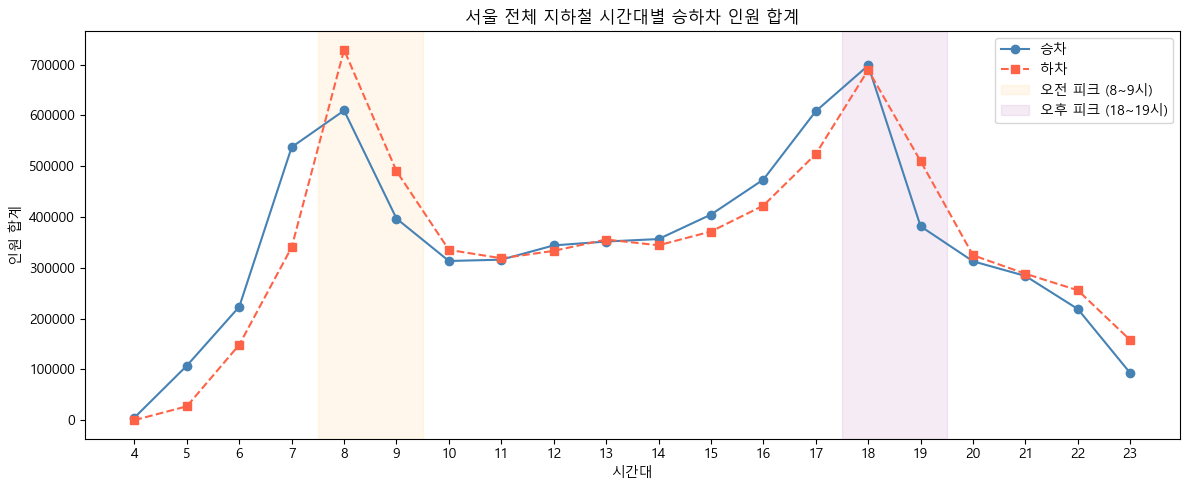

In [3]:
# 전체 역 합산 — 시간대별 평균 승하차 프로파일
total_by_hour = df_hourly.groupby('hour')[['avg_ride', 'avg_alight']].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(total_by_hour['hour'], total_by_hour['avg_ride'],   marker='o', label='승차', color='steelblue')
ax.plot(total_by_hour['hour'], total_by_hour['avg_alight'], marker='s', linestyle='--', label='하차', color='tomato')

# 출퇴근 피크 강조
ax.axvspan(7.5, 9.5,  alpha=0.08, color='orange', label='오전 피크 (8~9시)')
ax.axvspan(17.5, 19.5, alpha=0.08, color='purple', label='오후 피크 (18~19시)')

ax.set_title('서울 전체 지하철 시간대별 승하차 인원 합계')
ax.set_xlabel('시간대')
ax.set_ylabel('인원 합계')
ax.set_xticks(range(4, 24))
ax.legend()
plt.tight_layout()
plt.show()

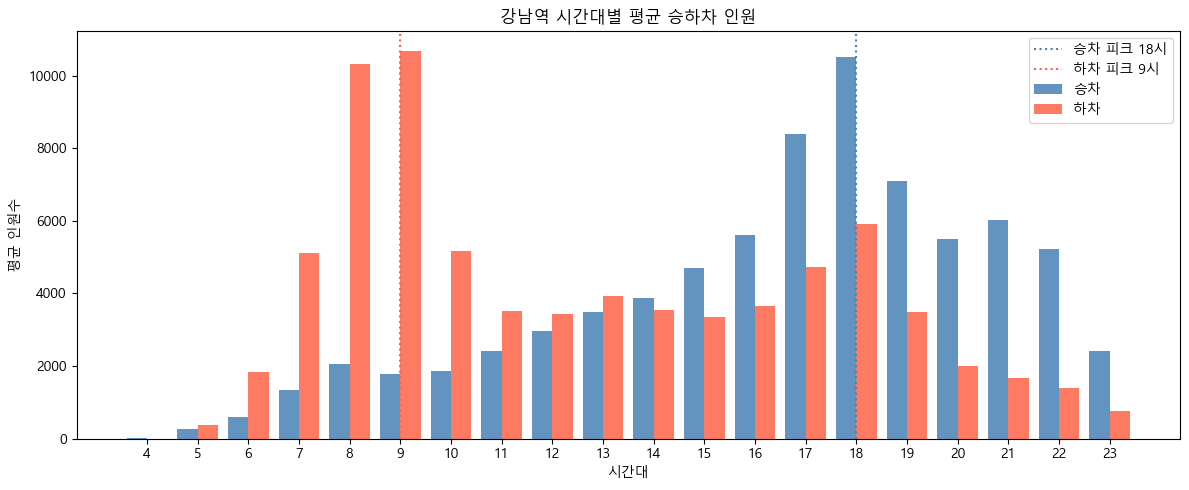

[강남] 승차 피크: 18시  하차 피크: 9시


In [4]:
# 특정 역 시간대별 패턴 (환승역은 호선별 합산)
station = '강남'
df_sta = df_hourly[df_hourly['subway_sta_nm'] == station].groupby('hour')[['avg_ride', 'avg_alight']].sum()

peak_ride_hour = int(df_sta['avg_ride'].idxmax())
peak_alight_hour = int(df_sta['avg_alight'].idxmax())

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_sta.index - 0.2, df_sta['avg_ride'],   width=0.4, label='승차',  color='steelblue', alpha=0.85)
ax.bar(df_sta.index + 0.2, df_sta['avg_alight'], width=0.4, label='하차', color='tomato',    alpha=0.85)

ax.axvline(peak_ride_hour,   color='steelblue', linestyle=':', linewidth=1.5, label=f'승차 피크 {peak_ride_hour}시')
ax.axvline(peak_alight_hour, color='tomato',    linestyle=':', linewidth=1.5, label=f'하차 피크 {peak_alight_hour}시')

ax.set_title(f'{station}역 시간대별 평균 승하차 인원')
ax.set_xlabel('시간대')
ax.set_ylabel('평균 인원수')
ax.set_xticks(range(4, 24))
ax.legend()
plt.tight_layout()
plt.show()
print(f'[{station}] 승차 피크: {peak_ride_hour}시  하차 피크: {peak_alight_hour}시')

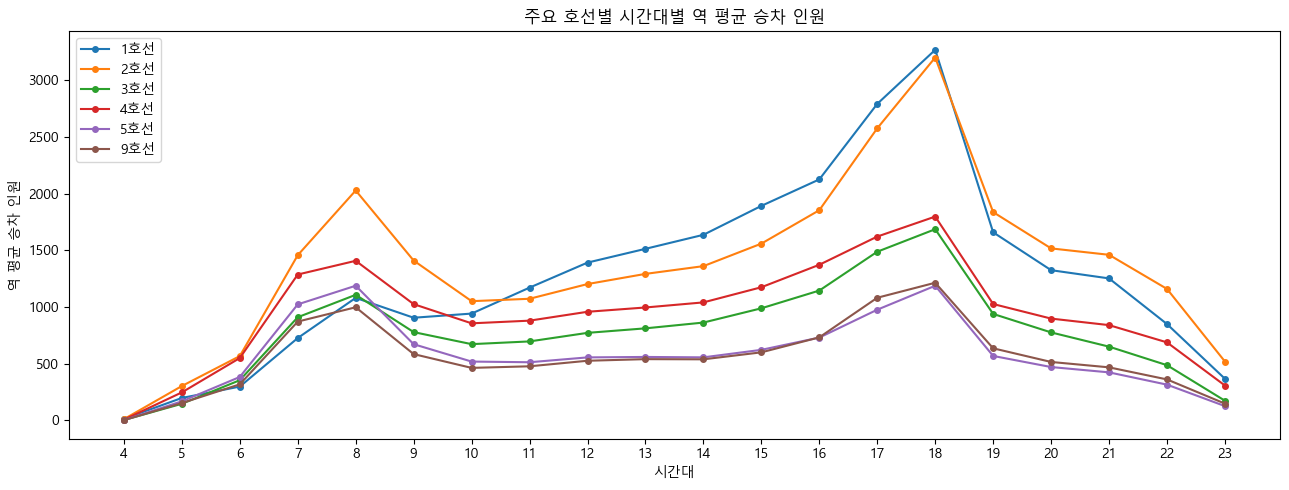

In [5]:
# 주요 호선별 시간대 평균 승차 비교
target_lines = ['1호선', '2호선', '3호선', '4호선', '5호선', '9호선']
df_line = df_hourly[df_hourly['line_num'].isin(target_lines)]
line_hour = df_line.groupby(['line_num', 'hour'])['avg_ride'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for line in target_lines:
    subset = line_hour[line_hour['line_num'] == line]
    ax.plot(subset['hour'], subset['avg_ride'], marker='o', markersize=4, label=line)

ax.set_title('주요 호선별 시간대별 역 평균 승차 인원')
ax.set_xlabel('시간대')
ax.set_ylabel('역 평균 승차 인원')
ax.set_xticks(range(4, 24))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

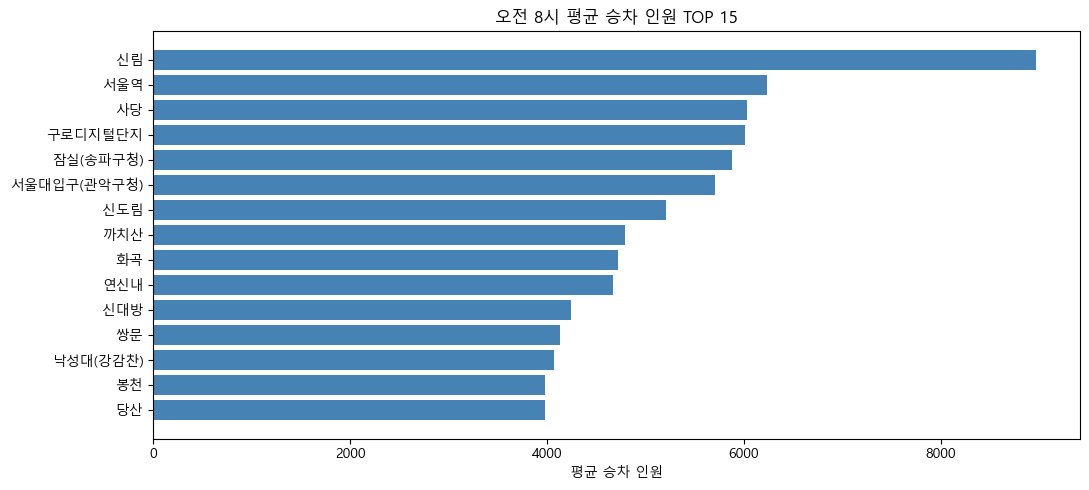

In [6]:
# 오전 8시 혼잡 역 TOP 15
rush_8 = df_hourly[df_hourly['hour'] == 8].groupby('subway_sta_nm')['avg_ride'].sum() \
    .sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(rush_8.index, rush_8.values, color='steelblue')
ax.set_title('오전 8시 평균 승차 인원 TOP 15')
ax.set_xlabel('평균 승차 인원')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

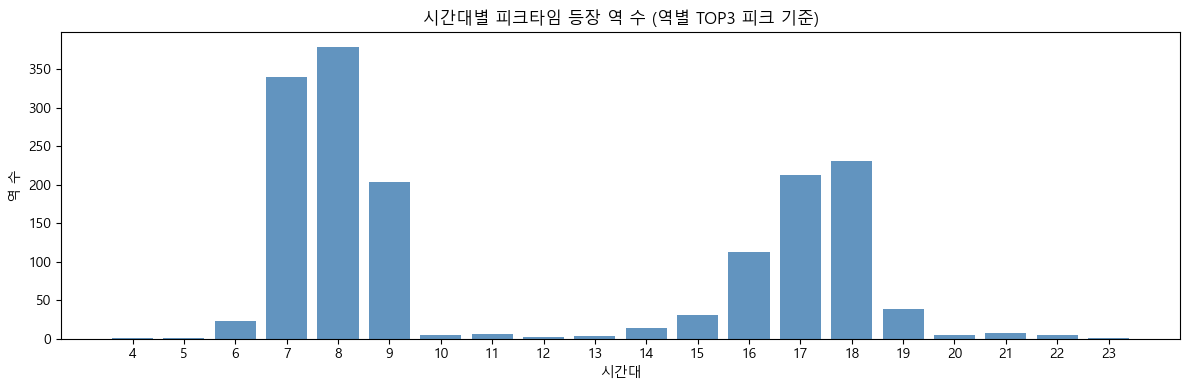

In [7]:
# Gold - 역별 피크타임 TOP3 로드
df_peak = spark.read.format('delta').load('data/gold/congestion_peak_hours').toPandas()

# 피크타임 시간대 분포 (전 역 기준)
peak_dist = df_peak.groupby('hour')['subway_sta_nm'].count().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(peak_dist.index, peak_dist.values, color='steelblue', alpha=0.85)
ax.set_title('시간대별 피크타임 등장 역 수 (역별 TOP3 피크 기준)')
ax.set_xlabel('시간대')
ax.set_ylabel('역 수')
ax.set_xticks(range(4, 24))
plt.tight_layout()
plt.show()

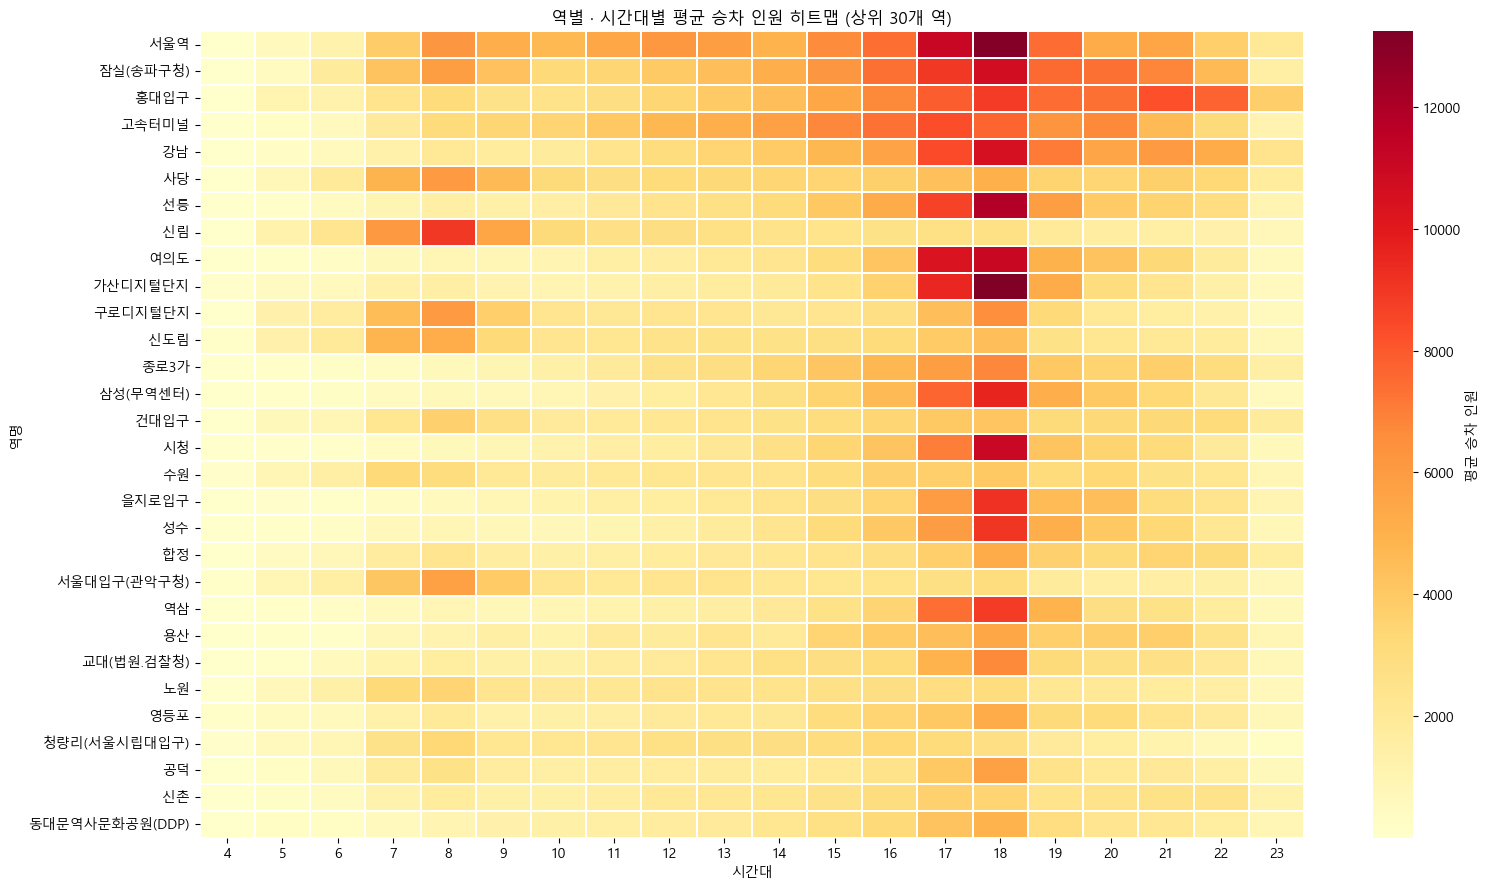

In [8]:
# 역 × 시간대 히트맵 (승차량 상위 30개 역)
top30_stations = df_hourly.groupby('subway_sta_nm')['avg_ride'].sum() \
    .sort_values(ascending=False).head(30).index.tolist()

df_top30 = df_hourly[df_hourly['subway_sta_nm'].isin(top30_stations)] \
    .groupby(['subway_sta_nm', 'hour'])['avg_ride'].sum().reset_index()

heatmap_pivot = df_top30.pivot(index='subway_sta_nm', columns='hour', values='avg_ride')
# 역을 총 승차량 기준으로 정렬
heatmap_pivot = heatmap_pivot.loc[top30_stations]

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap='YlOrRd',
    fmt='.0f',
    linewidths=0.3,
    cbar_kws={'label': '평균 승차 인원'}
)
ax.set_title('역별 · 시간대별 평균 승차 인원 히트맵 (상위 30개 역)')
ax.set_xlabel('시간대')
ax.set_ylabel('역명')
plt.tight_layout()
plt.show()

In [9]:
spark.stop()